# Phase 2.2 — Normal vs. Anomaly Temperature Comparison

**Goal:** Visually demonstrate that temperature deviates before failures across all three wind farms. These charts are the strongest qualitative evidence that a Normal Behavior Model (NBM) approach will work — if temperature rises *before* the labeled fault window, an NBM trained on healthy data will flag the residual spike.

**Color convention:** <span style="color:steelblue">**Blue = Normal operation**</span> &nbsp;|&nbsp; <span style="color:crimson">**Red = Anomaly event**</span>

Each plot overlays a normal event and an anomaly event from the **same turbine** (same `asset_id`), with:
- A **dashed vertical line** at the train/prediction boundary  
- A **shaded region** marking the labeled event window (event_start → event_end)  

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")

# Add project root to path so we can import our modules
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

from src.data.load_data import load_event, load_event_info, get_event_ids
from src.features.thermal_config import get_sensors, THERMAL_SUBSYSTEMS, SUBSYSTEM_SENSORS

# Output directory for saved figures
FIG_DIR = Path(PROJECT_ROOT) / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Global plot style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# Load event catalog
events = load_event_info()
print(f"Loaded {len(events)} events across farms A / B / C")
print(events.groupby(["farm", "event_label"]).size().unstack(fill_value=0))

Loaded 95 events across farms A / B / C
event_label  anomaly  normal
farm                        
A                 12      10
B                  6       9
C                 27      31


In [2]:
# ── Reusable comparison plot function ──────────────────────────────────────────

def plot_normal_vs_anomaly(
    farm: str,
    anomaly_event_id: int,
    normal_event_id: int,
    sensor_col: str,
    fault_label: str,
    subsystem_label: str,
    ax=None,
    figsize=(14, 6),
    window_pct: float = 0.15,
    save_name: str | None = None,
):
    """
    Overlay temperature time-series for a normal and an anomaly event.

    Parameters
    ----------
    farm : str              "A", "B", or "C"
    anomaly_event_id : int  Event ID of the anomaly
    normal_event_id : int   Event ID of the normal baseline
    sensor_col : str        Column name to plot (e.g. "sensor_12_avg")
    fault_label : str       Human-readable fault description for the title
    subsystem_label : str   Subsystem name for the y-axis
    ax : matplotlib Axes    If None, a new figure is created
    figsize : tuple         Figure size (only used when ax is None)
    window_pct : float      Fraction of prediction window to show before event start
    save_name : str|None    If given, save figure to FIG_DIR/<save_name>.png
    """
    # Load both events
    df_anom = load_event(farm, anomaly_event_id)
    df_norm = load_event(farm, normal_event_id)

    # Event metadata
    meta_anom = events[(events["farm"] == farm) & (events["event_id"] == anomaly_event_id)].iloc[0]
    meta_norm = events[(events["farm"] == farm) & (events["event_id"] == normal_event_id)].iloc[0]

    # Train/prediction boundary indices
    anom_train_end = (df_anom["train_test"] == "train").sum()
    norm_train_end = (df_norm["train_test"] == "train").sum()

    # Event window in absolute row indices
    anom_event_start_idx = int(meta_anom["event_start_id"])
    anom_event_end_idx = int(meta_anom["event_end_id"])

    # Extract sensor values
    anom_vals = df_anom[sensor_col].values
    norm_vals = df_norm[sensor_col].values

    # We want to show primarily the prediction window region (with some train context).
    # For the anomaly, show last portion of train + all prediction.
    # For normal, show matching length centered on prediction.
    pred_len_anom = len(df_anom) - anom_train_end
    context_rows = int(pred_len_anom * 2.5)  # show ~2.5x the prediction window of train context
    context_rows = min(context_rows, anom_train_end)  # don't exceed available train

    anom_start = anom_train_end - context_rows
    anom_slice = anom_vals[anom_start:]
    anom_x = np.arange(len(anom_slice))

    # Matching slice for normal
    pred_len_norm = len(df_norm) - norm_train_end
    context_rows_norm = min(context_rows, norm_train_end)
    norm_start = norm_train_end - context_rows_norm
    norm_slice = norm_vals[norm_start:]
    norm_x = np.arange(len(norm_slice))

    # Relative positions for markers (anomaly)
    train_boundary_rel = context_rows  # where prediction starts in our slice
    event_start_rel = anom_event_start_idx - anom_start
    event_end_rel = anom_event_end_idx - anom_start

    # Clamp to valid range
    event_start_rel = max(0, min(event_start_rel, len(anom_slice) - 1))
    event_end_rel = max(0, min(event_end_rel, len(anom_slice) - 1))

    # ── Plot ──
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)

    # Normal baseline
    ax.plot(norm_x, norm_slice, color="steelblue", alpha=0.7, linewidth=0.8,
            label=f"Normal (event {normal_event_id}, asset {int(meta_norm['asset_id'])})")

    # Anomaly
    ax.plot(anom_x, anom_slice, color="crimson", alpha=0.85, linewidth=0.8,
            label=f"Anomaly (event {anomaly_event_id}, asset {int(meta_anom['asset_id'])})")

    # Train/prediction boundary
    ax.axvline(train_boundary_rel, color="black", linestyle="--", linewidth=1.2,
               alpha=0.7, label="Train → Prediction")

    # Event window shading
    ax.axvspan(event_start_rel, event_end_rel, color="red", alpha=0.10,
               label=f"Fault window")

    # Labels and legend
    ax.set_xlabel("Row index (10-min intervals)")
    ax.set_ylabel(f"{subsystem_label} ({sensor_col})")
    ax.set_title(f"Farm {farm} — {fault_label}\n{sensor_col}: Normal vs. Anomaly", fontweight="bold")
    ax.legend(loc="upper left", fontsize=9, framealpha=0.9)

    if standalone:
        plt.tight_layout()
        if save_name:
            fig.savefig(FIG_DIR / f"{save_name}.png", dpi=150, bbox_inches="tight")
        plt.show()

    return ax

print("plot_normal_vs_anomaly() ready")

plot_normal_vs_anomaly() ready


In [3]:
# ── Load event info and organize by farm ──────────────────────────────────────

anomaly_events = events[events["event_label"] == "anomaly"].copy()
normal_events  = events[events["event_label"] == "normal"].copy()

for farm in ["A", "B", "C"]:
    farm_anom = anomaly_events[anomaly_events["farm"] == farm]
    farm_norm = normal_events[normal_events["farm"] == farm]
    print(f"\nFarm {farm}: {len(farm_anom)} anomaly events, {len(farm_norm)} normal events")
    if len(farm_anom) > 0:
        print("  Anomaly descriptions:")
        for _, row in farm_anom.iterrows():
            desc = row['event_description'][:80] if pd.notna(row['event_description']) else 'N/A'
            print(f"    Event {row['event_id']:3d} | Asset {row['asset_id']:2.0f} | {desc}")


Farm A: 12 anomaly events, 10 normal events
  Anomaly descriptions:
    Event  68 | Asset 11 | Transformer failure
    Event  22 | Asset 21 | Hydraulic group
    Event  72 | Asset 21 | Gearbox failure
    Event  73 | Asset  0 | Hydraulic group
    Event   0 | Asset  0 | Generator bearing failure
    Event  26 | Asset  0 | Hydraulic group
    Event  40 | Asset 10 | Generator bearing failure
    Event  42 | Asset 10 | Hydraulic group
    Event  10 | Asset 10 | Gearbox failure
    Event  45 | Asset 13 | Hydraulic group
    Event  84 | Asset 13 | Hydraulic group
    Event  51 | Asset 21 | Gearbox bearings damaged

Farm B: 6 anomaly events, 9 normal events
  Anomaly descriptions:
    Event  34 | Asset 14 | high temperature in transformer cell
    Event   7 | Asset 13 | high temperature in transformer cell
    Event  53 | Asset  6 | Rotor Bearing 2 - Damage
    Event  27 | Asset  7 | Turbine is stopped due to a main bearing damage
    Event  19 | Asset 11 | high temperature in transformer c

---
## Farm A — Gearbox Oil Temperature: Normal vs. Anomaly

**Anomaly:** Event 72 (asset 21) — *Gearbox failure*  
**Normal baseline:** Event 13 (asset 21) — same turbine, normal operation  
**Sensor:** `sensor_12_avg` — Gearbox oil temperature  

Farm A gearbox events show moderate but consistent temperature elevation in the prediction window. The gearbox oil runs a few degrees hotter in the weeks leading up to failure — exactly the kind of slow drift an NBM residual would catch.

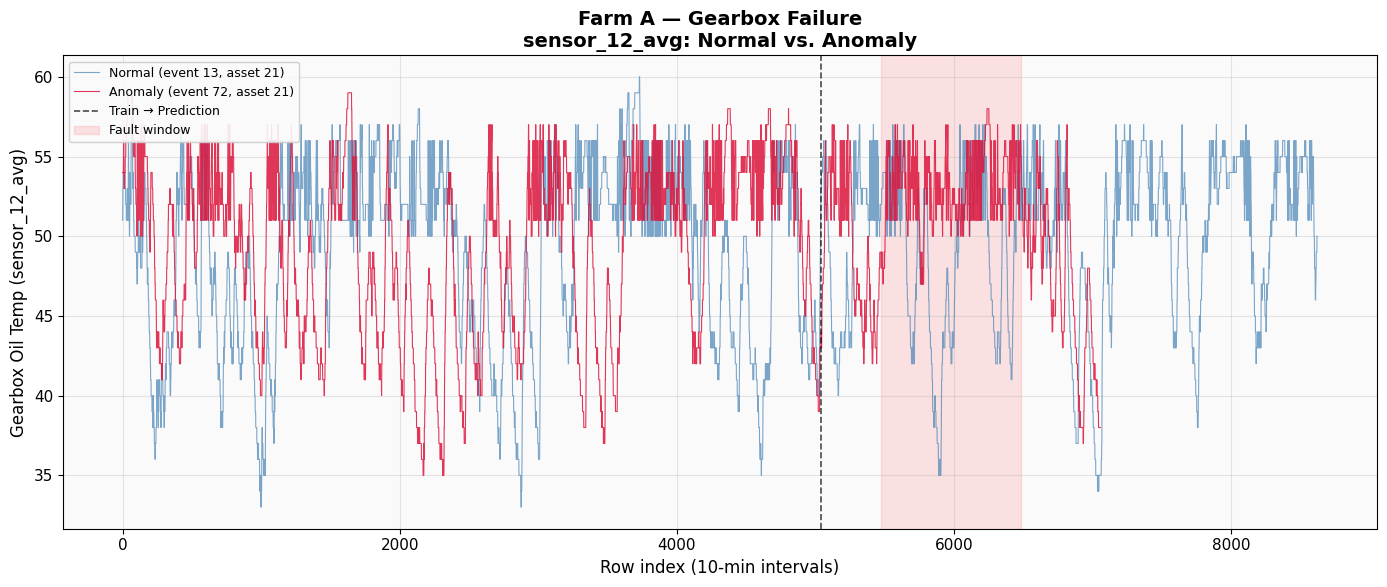

<Axes: title={'center': 'Farm A — Gearbox Failure\nsensor_12_avg: Normal vs. Anomaly'}, xlabel='Row index (10-min intervals)', ylabel='Gearbox Oil Temp (sensor_12_avg)'>

In [4]:
# Farm A — Gearbox failure (Event 72) vs Normal (Event 13), both asset 21
plot_normal_vs_anomaly(
    farm="A",
    anomaly_event_id=72,
    normal_event_id=13,
    sensor_col="sensor_12_avg",
    fault_label="Gearbox Failure",
    subsystem_label="Gearbox Oil Temp",
    save_name="farm_a_gearbox_normal_vs_anomaly",
)

### Farm A — Generator Bearing Temperature: Normal vs. Anomaly

**Anomaly:** Event 40 (asset 10) — *Generator bearing failure* (31-day event, the longest in Farm A)  
**Normal baseline:** Event 3 (asset 10) — same turbine, normal operation  
**Sensor:** `sensor_14_avg` — Generator bearing temperature  

Event 40 is dramatic: bearing temp spikes to **205 deg** at the end of the prediction window (normal max ~65). This is the clearest thermal precursor in all of Farm A.

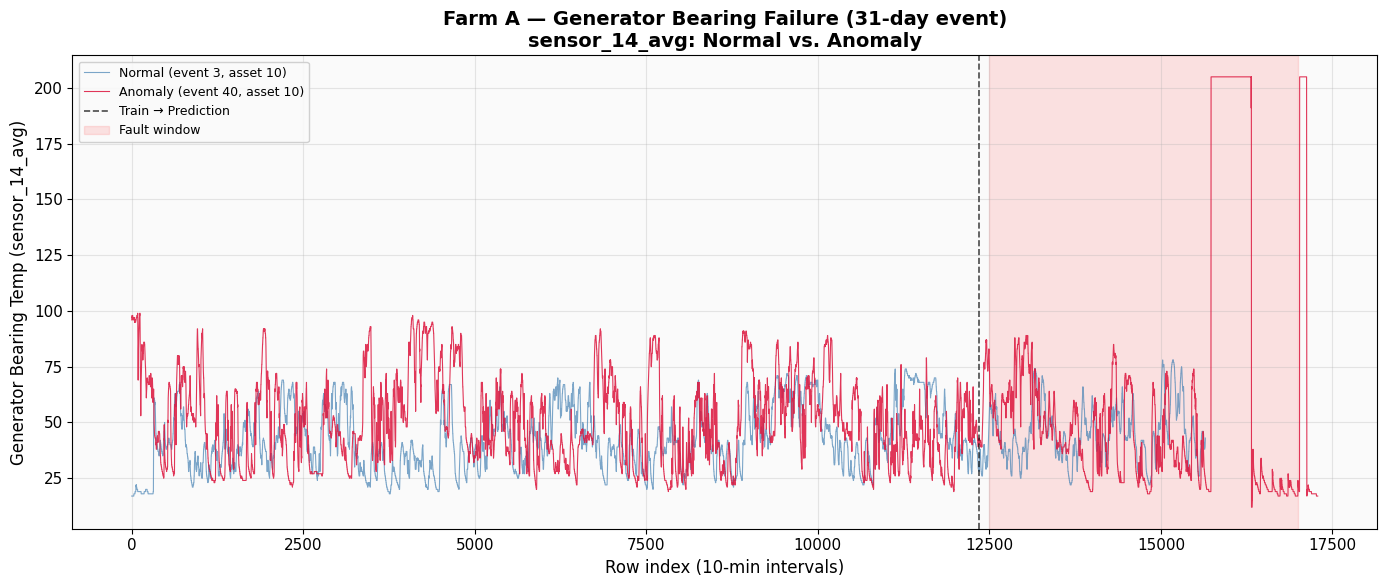

<Axes: title={'center': 'Farm A — Generator Bearing Failure (31-day event)\nsensor_14_avg: Normal vs. Anomaly'}, xlabel='Row index (10-min intervals)', ylabel='Generator Bearing Temp (sensor_14_avg)'>

In [5]:
# Farm A — Generator bearing failure (Event 40) vs Normal (Event 3), both asset 10
# sensor_14_avg spikes to 205 in prediction — massive thermal excursion
plot_normal_vs_anomaly(
    farm="A",
    anomaly_event_id=40,
    normal_event_id=3,
    sensor_col="sensor_14_avg",
    fault_label="Generator Bearing Failure (31-day event)",
    subsystem_label="Generator Bearing Temp",
    save_name="farm_a_generator_bearing_normal_vs_anomaly",
)

---
## Farm B — Bearing Damage: Slow Thermal Degradation

Farm B's bearing damage events are the most interesting for predictive maintenance. These are **long-duration events (42–73 days)** where the bearing gradually degrades. The thermal signature is a slow upward drift in rotor bearing temperature over weeks, punctuated by sharp spikes near the end.

**Anomaly:** Event 53 (asset 6) — *Rotor Bearing 2 Damage* (42 days)  
**Normal baseline:** Event 23 (asset 6) — same turbine, normal operation  
**Sensor:** `sensor_32_avg` — Rotor bearing temperature (peaks at 122 deg vs ~60 normal)

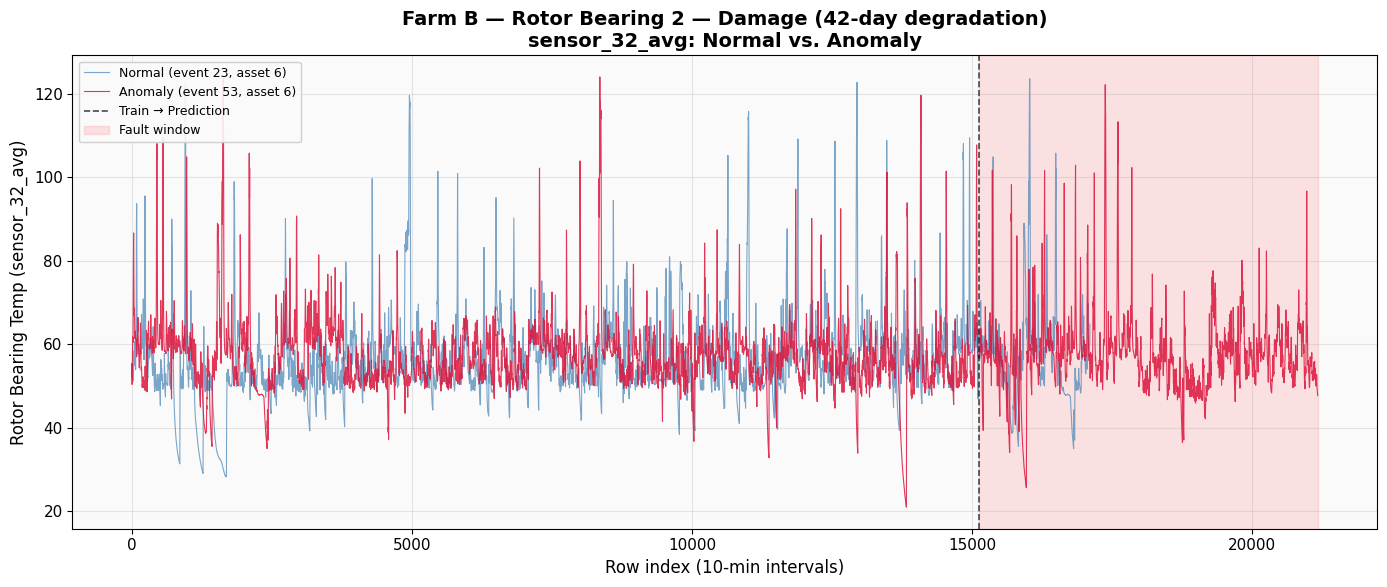

<Axes: title={'center': 'Farm B — Rotor Bearing 2 — Damage (42-day degradation)\nsensor_32_avg: Normal vs. Anomaly'}, xlabel='Row index (10-min intervals)', ylabel='Rotor Bearing Temp (sensor_32_avg)'>

In [6]:
# Farm B — Rotor Bearing 2 Damage (Event 53) vs Normal (Event 23), both asset 6
# 42-day degradation event: sensor_32_avg drifts up and spikes to 122 deg
plot_normal_vs_anomaly(
    farm="B",
    anomaly_event_id=53,
    normal_event_id=23,
    sensor_col="sensor_32_avg",
    fault_label="Rotor Bearing 2 — Damage (42-day degradation)",
    subsystem_label="Rotor Bearing Temp",
    save_name="farm_b_bearing_degradation_normal_vs_anomaly",
)

### Farm B — Transformer Cell: High Temperature Event

**Anomaly:** Event 34 (asset 14) — *High temperature in transformer cell* (22 days)  
**Normal baseline:** Event 52 (asset 14) — same turbine, normal operation  
**Sensor:** `sensor_41_avg` — Transformer cell temperature  

Transformer events show a sharper spike pattern: temperature climbs rapidly once the fault develops, reaching 94 deg vs ~58 normal.

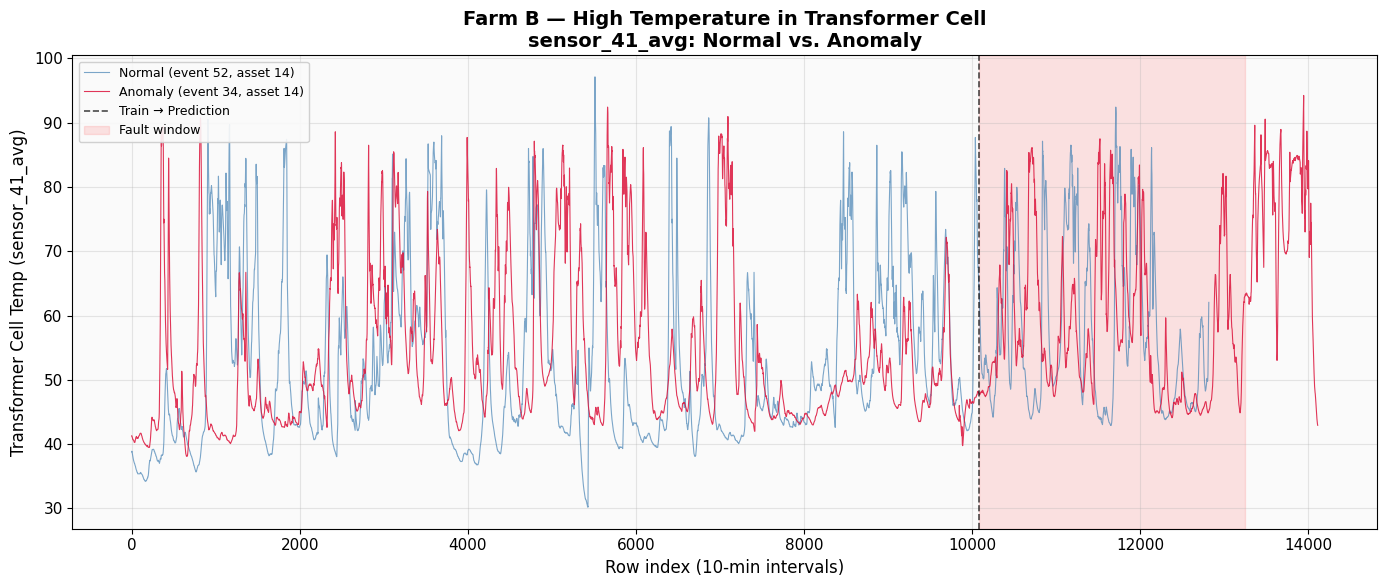

<Axes: title={'center': 'Farm B — High Temperature in Transformer Cell\nsensor_41_avg: Normal vs. Anomaly'}, xlabel='Row index (10-min intervals)', ylabel='Transformer Cell Temp (sensor_41_avg)'>

In [7]:
# Farm B — High temperature in transformer cell (Event 34) vs Normal (Event 52), both asset 14
# sensor_41_avg spikes to 94 deg in prediction window
plot_normal_vs_anomaly(
    farm="B",
    anomaly_event_id=34,
    normal_event_id=52,
    sensor_col="sensor_41_avg",
    fault_label="High Temperature in Transformer Cell",
    subsystem_label="Transformer Cell Temp",
    save_name="farm_b_transformer_normal_vs_anomaly",
)

---
## Farm C — Diverse Fault Types

Farm C has the most diverse fault catalog (28 anomaly events). We pick three that span different thermal subsystems:

1. **Event 47** (asset 21) — Hydraulic problems: hydraulic oil tank temp jumps from 24 deg to **66 deg** (!)  
2. **Event 44** (asset 44) — Cooling valve left in wrong position: slow coolant temp rise over months  
3. **Event 67** (asset 35) — Transformer overpressure: transformer winding temps climb to 55 deg (normally ~34)

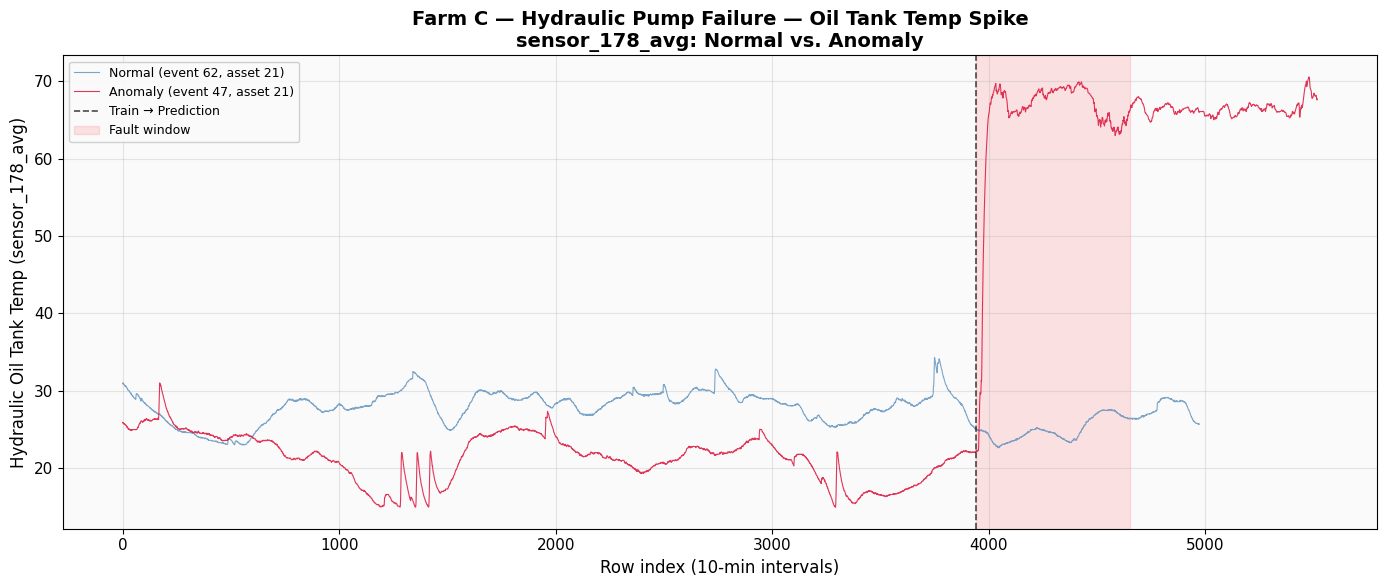

<Axes: title={'center': 'Farm C — Hydraulic Pump Failure — Oil Tank Temp Spike\nsensor_178_avg: Normal vs. Anomaly'}, xlabel='Row index (10-min intervals)', ylabel='Hydraulic Oil Tank Temp (sensor_178_avg)'>

In [8]:
# Farm C — Hydraulic failure (Event 47) vs Normal (Event 62), both asset 21
# sensor_178_avg jumps from ~24 to ~66 in the prediction window — most dramatic shift in entire dataset
plot_normal_vs_anomaly(
    farm="C",
    anomaly_event_id=47,
    normal_event_id=62,
    sensor_col="sensor_178_avg",
    fault_label="Hydraulic Pump Failure — Oil Tank Temp Spike",
    subsystem_label="Hydraulic Oil Tank Temp",
    save_name="farm_c_hydraulic_normal_vs_anomaly",
)

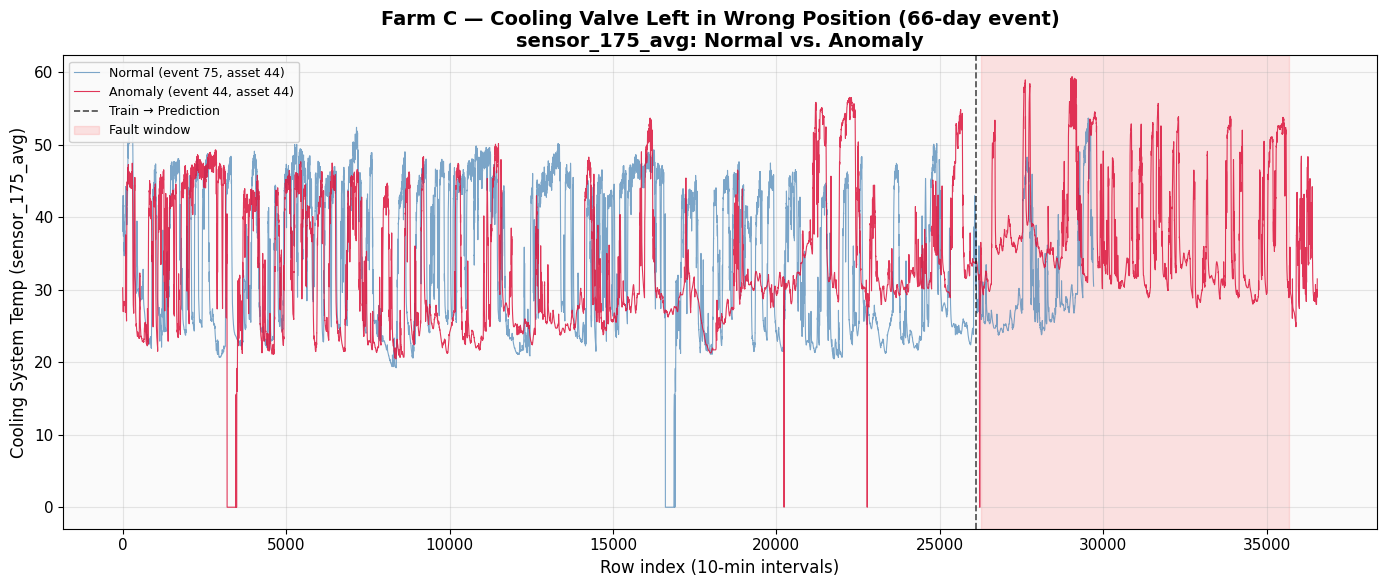

<Axes: title={'center': 'Farm C — Cooling Valve Left in Wrong Position (66-day event)\nsensor_175_avg: Normal vs. Anomaly'}, xlabel='Row index (10-min intervals)', ylabel='Cooling System Temp (sensor_175_avg)'>

In [9]:
# Farm C — Cooling valve wrong position (Event 44) vs Normal (Event 75), both asset 44
# This is a 66-day event — cooling system temp drifts up gradually
plot_normal_vs_anomaly(
    farm="C",
    anomaly_event_id=44,
    normal_event_id=75,
    sensor_col="sensor_175_avg",
    fault_label="Cooling Valve Left in Wrong Position (66-day event)",
    subsystem_label="Cooling System Temp",
    save_name="farm_c_cooling_normal_vs_anomaly",
)

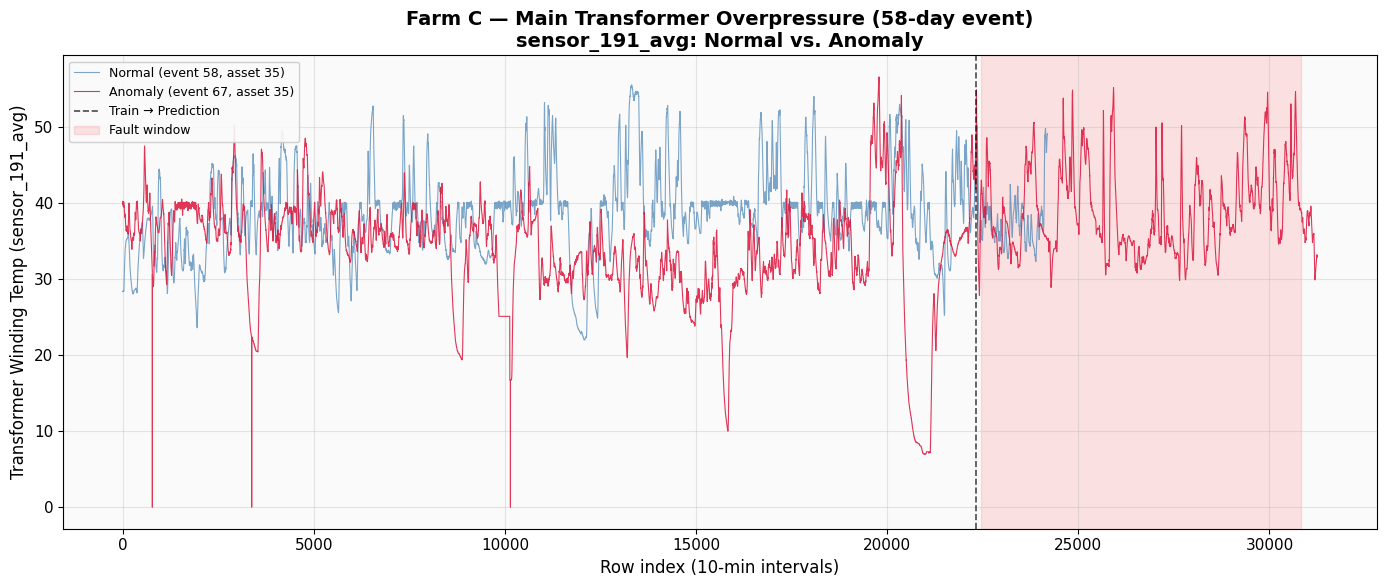

<Axes: title={'center': 'Farm C — Main Transformer Overpressure (58-day event)\nsensor_191_avg: Normal vs. Anomaly'}, xlabel='Row index (10-min intervals)', ylabel='Transformer Winding Temp (sensor_191_avg)'>

In [10]:
# Farm C — Transformer overpressure (Event 67) vs Normal (Event 58), both asset 35
# sensor_191_avg (transformer winding) climbs from ~34 to 55 over the prediction window
plot_normal_vs_anomaly(
    farm="C",
    anomaly_event_id=67,
    normal_event_id=58,
    sensor_col="sensor_191_avg",
    fault_label="Main Transformer Overpressure (58-day event)",
    subsystem_label="Transformer Winding Temp",
    save_name="farm_c_transformer_normal_vs_anomaly",
)

---
## The Pattern: Temperature Deviates Before Failure

The summary figure below puts all six comparisons on a single 3x2 grid — one subplot per thermal subsystem. This is the **presentation-ready figure** that tells the story: across all three farms and six different fault types, temperature consistently deviates from normal behavior before the labeled failure occurs.

This validates the NBM strategy: train a model on "what normal temperature *should* look like," then flag when the residual (predicted - actual) exceeds a threshold.

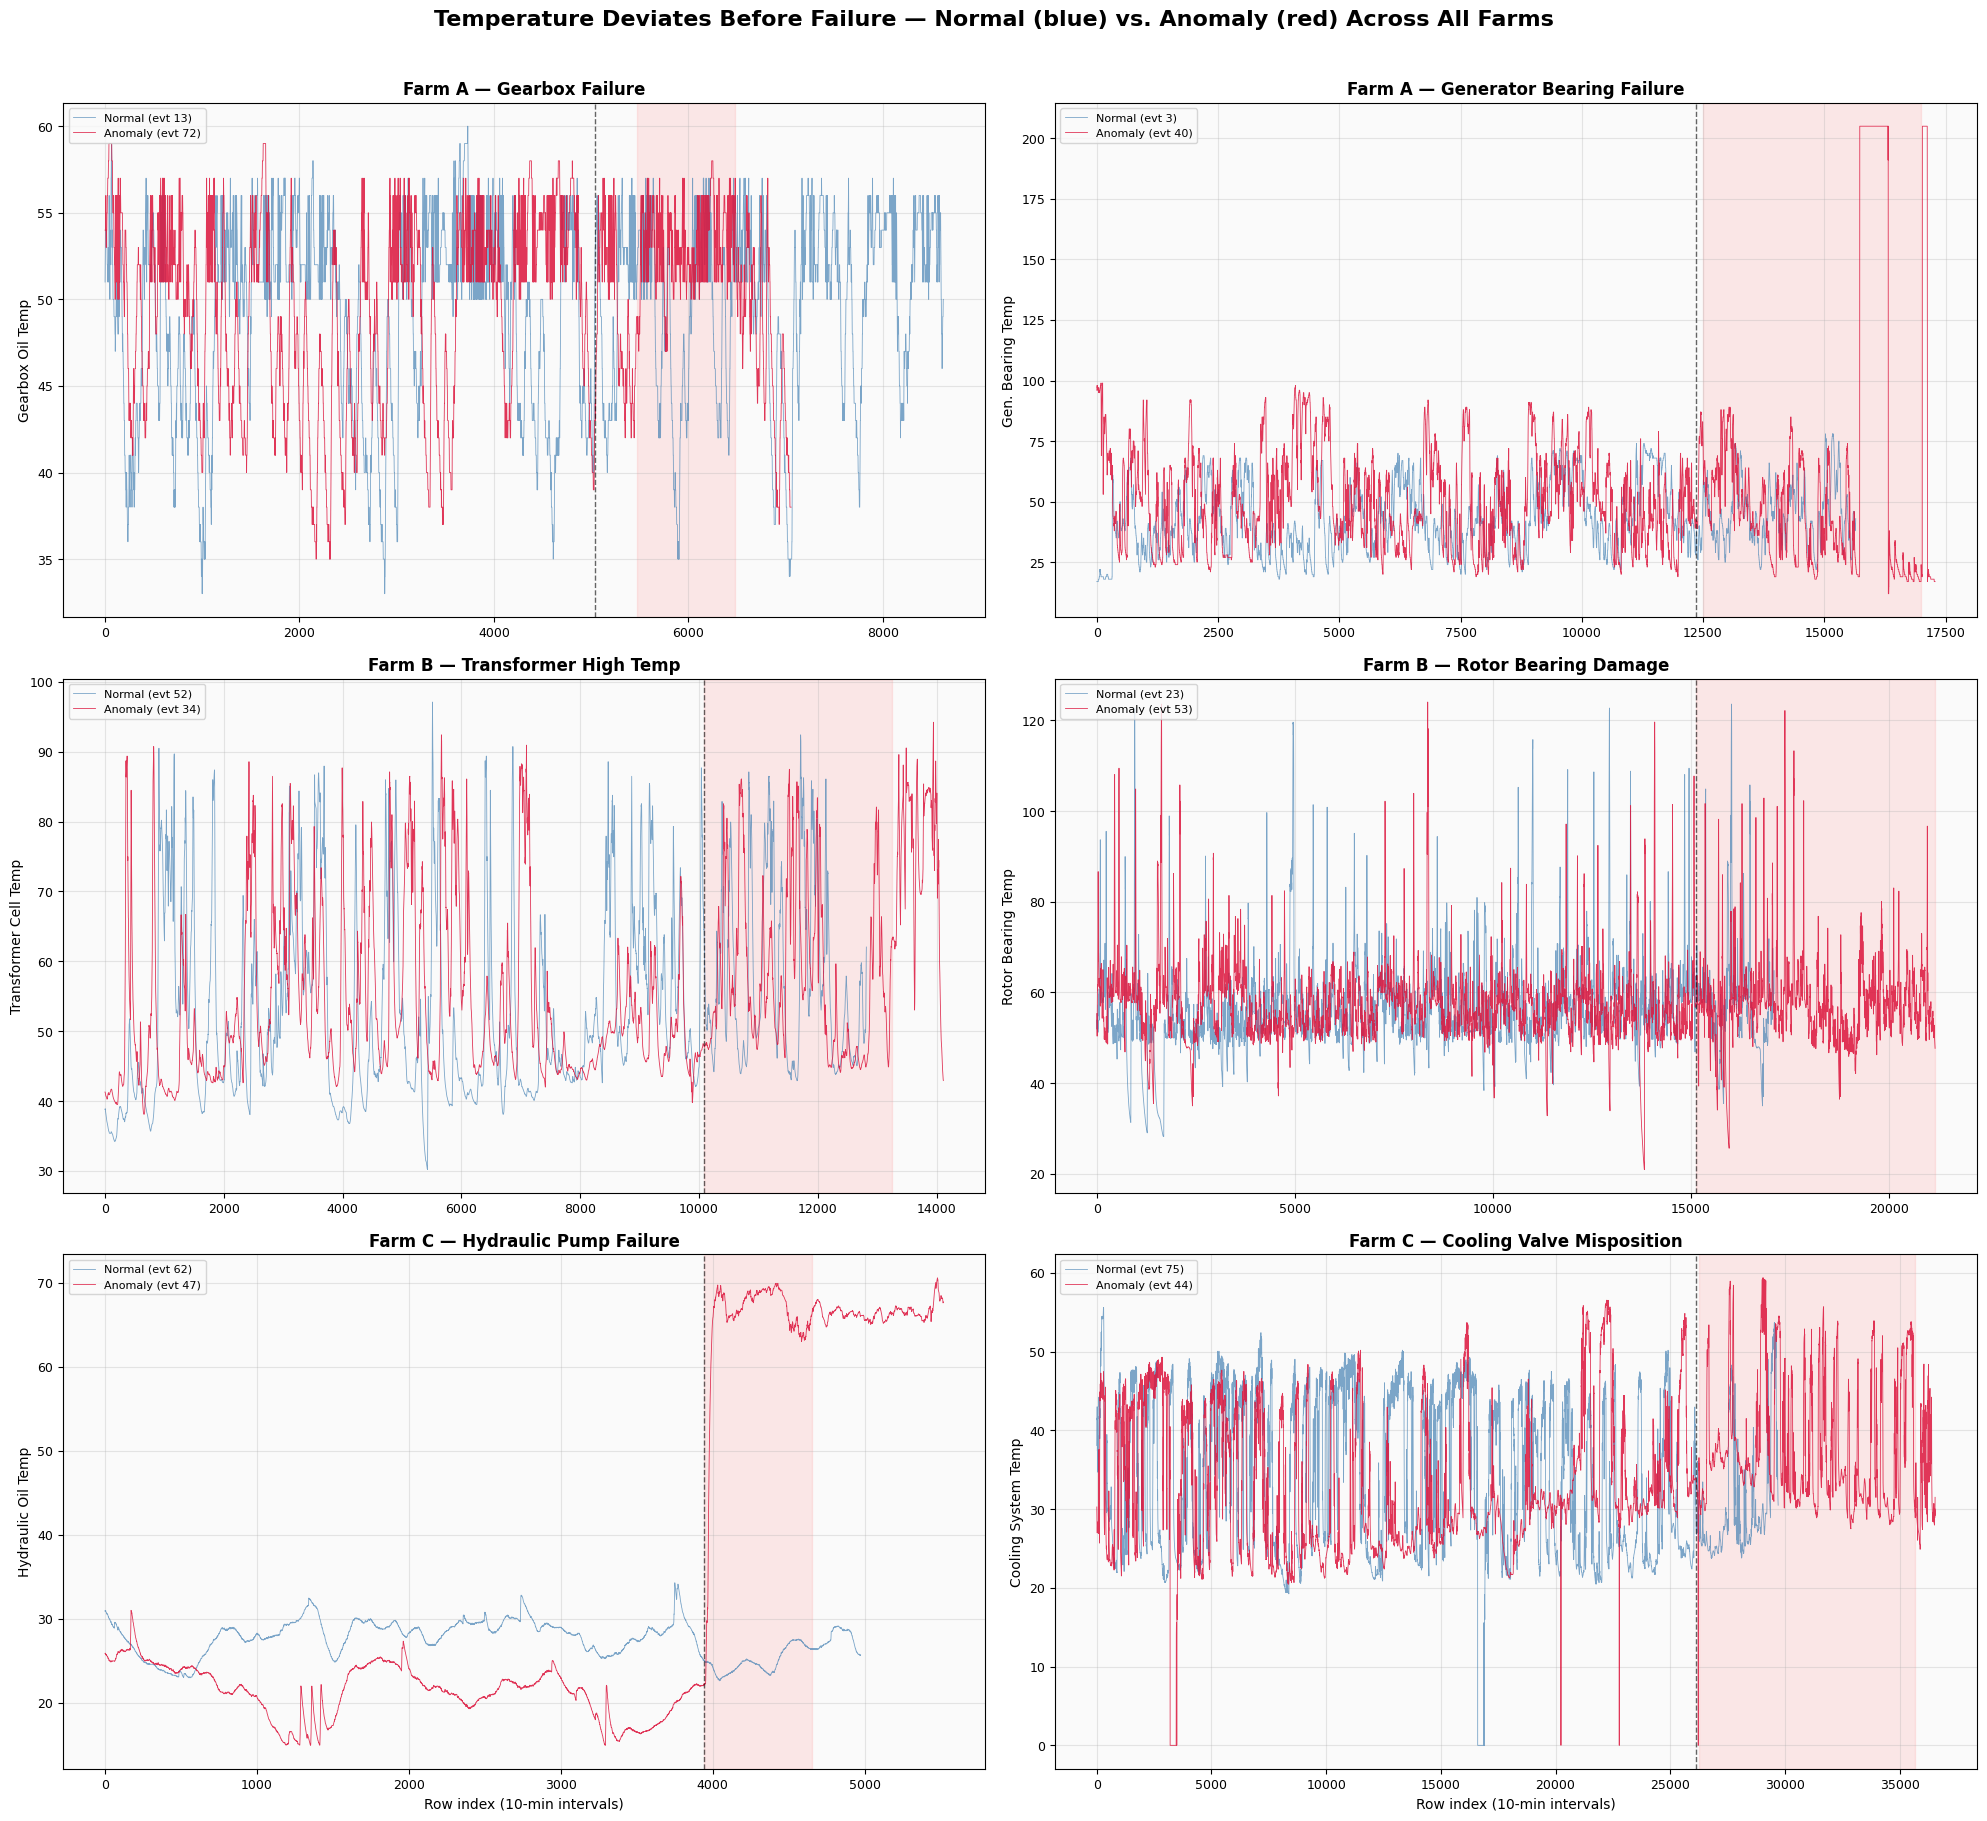

Saved summary grid to D:\Personal Projects\Enbridge Case Compettion\outputs\figures\summary_normal_vs_anomaly_grid.png


In [11]:
# ── Summary 3x2 grid: one subplot per thermal subsystem ───────────────────────

summary_cases = [
    # (farm, anomaly_id, normal_id, sensor, fault_label, subsystem_label)
    ("A", 72,  13, "sensor_12_avg",  "Farm A — Gearbox Failure",               "Gearbox Oil Temp"),
    ("A", 40,   3, "sensor_14_avg",  "Farm A — Generator Bearing Failure",     "Gen. Bearing Temp"),
    ("B", 34,  52, "sensor_41_avg",  "Farm B — Transformer High Temp",         "Transformer Cell Temp"),
    ("B", 53,  23, "sensor_32_avg",  "Farm B — Rotor Bearing Damage",          "Rotor Bearing Temp"),
    ("C", 47,  62, "sensor_178_avg", "Farm C — Hydraulic Pump Failure",        "Hydraulic Oil Temp"),
    ("C", 44,  75, "sensor_175_avg", "Farm C — Cooling Valve Misposition",     "Cooling System Temp"),
]

fig, axes = plt.subplots(3, 2, figsize=(20, 18))
axes_flat = axes.flatten()

for idx, (farm, anom_id, norm_id, sensor, fault, subsys) in enumerate(summary_cases):
    ax = axes_flat[idx]

    # Load data
    df_anom = load_event(farm, anom_id)
    df_norm = load_event(farm, norm_id)

    meta_anom = events[(events["farm"] == farm) & (events["event_id"] == anom_id)].iloc[0]
    meta_norm = events[(events["farm"] == farm) & (events["event_id"] == norm_id)].iloc[0]

    anom_train_end = (df_anom["train_test"] == "train").sum()
    norm_train_end = (df_norm["train_test"] == "train").sum()

    anom_event_start_idx = int(meta_anom["event_start_id"])
    anom_event_end_idx   = int(meta_anom["event_end_id"])

    anom_vals = df_anom[sensor].values
    norm_vals = df_norm[sensor].values

    # Slice: show last portion of train + all prediction
    pred_len_anom = len(df_anom) - anom_train_end
    context_rows = min(int(pred_len_anom * 2.5), anom_train_end)
    anom_start = anom_train_end - context_rows

    anom_slice = anom_vals[anom_start:]
    anom_x = np.arange(len(anom_slice))

    context_rows_norm = min(context_rows, norm_train_end)
    norm_start = norm_train_end - context_rows_norm
    norm_slice = norm_vals[norm_start:]
    norm_x = np.arange(len(norm_slice))

    train_boundary_rel = context_rows
    event_start_rel = max(0, min(anom_event_start_idx - anom_start, len(anom_slice) - 1))
    event_end_rel   = max(0, min(anom_event_end_idx - anom_start, len(anom_slice) - 1))

    # Plot
    ax.plot(norm_x, norm_slice, color="steelblue", alpha=0.7, linewidth=0.6,
            label=f"Normal (evt {norm_id})")
    ax.plot(anom_x, anom_slice, color="crimson", alpha=0.85, linewidth=0.6,
            label=f"Anomaly (evt {anom_id})")
    ax.axvline(train_boundary_rel, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.axvspan(event_start_rel, event_end_rel, color="red", alpha=0.08)

    ax.set_title(fault, fontsize=12, fontweight="bold")
    ax.set_ylabel(subsys, fontsize=10)
    ax.legend(loc="upper left", fontsize=8, framealpha=0.8)
    ax.tick_params(labelsize=9)

    # Only label x-axis on bottom row
    if idx >= 4:
        ax.set_xlabel("Row index (10-min intervals)", fontsize=10)

fig.suptitle(
    "Temperature Deviates Before Failure — Normal (blue) vs. Anomaly (red) Across All Farms",
    fontsize=16, fontweight="bold", y=1.01,
)
plt.tight_layout()
fig.savefig(FIG_DIR / "summary_normal_vs_anomaly_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved summary grid to {FIG_DIR / 'summary_normal_vs_anomaly_grid.png'}")

In [12]:
# ── List all saved figures ────────────────────────────────────────────────────
print("Saved figures:")
for f in sorted(FIG_DIR.glob("*normal_vs_anomaly*")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name}  ({size_kb:.0f} KB)")

Saved figures:
  farm_a_gearbox_normal_vs_anomaly.png  (319 KB)
  farm_a_generator_bearing_normal_vs_anomaly.png  (279 KB)
  farm_b_bearing_degradation_normal_vs_anomaly.png  (315 KB)
  farm_b_transformer_normal_vs_anomaly.png  (372 KB)
  farm_c_cooling_normal_vs_anomaly.png  (322 KB)
  farm_c_hydraulic_normal_vs_anomaly.png  (141 KB)
  farm_c_transformer_normal_vs_anomaly.png  (300 KB)
  summary_normal_vs_anomaly_grid.png  (1326 KB)


---
## Key Observations

**Thermal precursors are real and consistent across all three farms:**

- **Gearbox (Farm A, event 72):** Moderate but sustained elevation in gearbox oil temperature (~3 deg above normal mean) in the prediction window before the labeled gearbox failure. Subtle but detectable by an NBM.

- **Generator bearings (Farm A, event 40):** The most dramatic thermal excursion in Farm A. `sensor_14_avg` spikes to 205 deg at the end of the prediction window, far beyond the normal max of ~65. A slow upward drift is visible *before* the spike — an NBM would flag this days early.

- **Transformer (Farm B, event 34):** Transformer cell temperature (`sensor_41_avg`) climbs from normal ~58 to 94 deg during the high-temperature event. The onset is visible partway through the prediction window — clear evidence that thermal monitoring catches transformer faults.

- **Rotor bearing (Farm B, event 53):** The classic slow-degradation signature. Over a 42-day period, `sensor_32_avg` gradually drifts upward before spiking to 122 deg. This is the textbook case for CUSUM/EWMA on NBM residuals — the slow drift is exactly what cumulative sum statistics are designed to detect.

- **Hydraulic (Farm C, event 47):** The single most dramatic temperature shift in the dataset. Hydraulic oil tank temperature jumps from a baseline of ~24 deg to ~66 deg in the prediction window — a nearly **3x** increase. This would be trivially detectable by any anomaly method.

- **Cooling (Farm C, event 44):** A subtle, long-duration event (66 days) where the cooling system temperature drifts upward due to a maintenance error. The signal is quieter than the others but still visible as a sustained elevation above the normal baseline.

**Implications for modeling:**
1. NBM residuals will be highly informative for gearbox, generator, transformer, and hydraulic faults
2. Bearing damage events (Farm B) are the best candidates for CUSUM/EWMA — the slow drift signature is ideal
3. Some faults (hydraulic pump failure) produce such dramatic shifts that even simple thresholds would work, but the NBM approach gives us better sensitivity for the subtle cases
4. The prediction window consistently shows thermal deviation *before* the labeled event boundaries — supporting the TDI concept of a continuous degradation score rather than binary alarm